<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Executivo_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Card-Executivo-Ícone

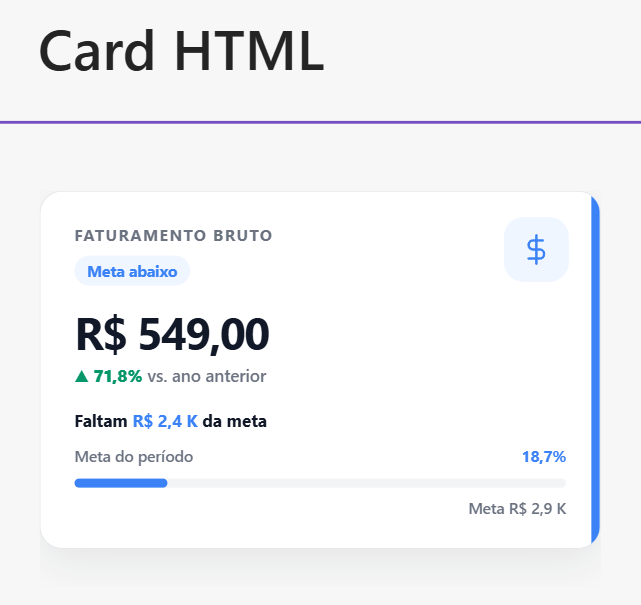

In [ ]:
HTML card-executivo-icone =
//======================================================
//==================== VALORES ========================
VAR Fat         = [faturamento_bruto]
VAR Meta        = [faturamento_bruto_meta]
VAR YoY         = [faturamento_bruto YoY %]
VAR Ating       = [%atingimento_meta]

//======================================================

-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║      Card executivo com ícone no canto superior direito         ║
-- ╚══════════════════════════════════════════════════════════════════╝


-- ──────── 🏷️ TEXTOS ────────
VAR varTitulo           = "Faturamento Bruto"
VAR varLabelMeta        = "Meta do período"
VAR varComparativo      = "vs. ano anterior"
VAR TextoMetaOk         = "Meta atingida"
VAR TextoMetaAbaixo     = "Meta abaixo"
VAR TextoFaltaMeta      = "Faltam"
VAR TextoExcedeuMeta    = "Superou em"


-- ──────── 🎨 CORES ────────
VAR CorFundo            = "#FFFFFF"
VAR CorBorda            = "#E5E7EB"
VAR CorTitulo           = "#6B7280"
VAR CorValor            = "#111827"
VAR CorTextoSuave       = "#6B7280"
VAR CorBarraFundo       = "#F3F4F6"

VAR CorPosi             = "#059669"
VAR CorNega             = "#DC2626"

-- Status da meta
VAR CorStatusOk         = "#059669"
VAR CorStatusAbaixo     = "#3B82F6"

-- Fundo do pill / ícone
VAR CorPillOk           = "#ECFDF5"
VAR CorPillAbaixo       = "#EFF6FF"

-- Detalhe colorido
VAR CorDetalheOk        = "#059669"
VAR CorDetalheAbaixo    = "#3B82F6"


-- ──────── 🌈 DETALHE COLORIDO ────────
-- Opções: "esquerda", "direita", "topo", "baixo", "nenhuma"
VAR PosicaoDetalhe      = "direita"
VAR LarguraDetalhe      = "6px"


-- ──────── 🎨 ÍCONE ────────
-- TRUE = mostra o ícone no canto superior direito destacado na imagem.
-- FALSE = esconde o ícone.
VAR MostrarIcone        = TRUE()

-- Posição absoluta do ícone dentro do card.
VAR IconeTop            = "18px"
VAR IconeRight          = "22px"

-- Ícone padrão: meta/check
VAR IconePath =
 "M12 1v22M17 5H9.5a3.5 3.5 0 000 7h5a3.5 3.5 0 010 7H6"

VAR TamanhoCaixaIcone  = "46px"
VAR RaioCaixaIcone     = "14px"
VAR StrokeIcone        = "1.9"


-- ──────── 📐 LAYOUT ────────
VAR RaioBorda           = "16px"
VAR Padding             = "22px 24px 20px 24px"
VAR SombraCard          = "0 10px 28px rgba(17,24,39,.07)"


-- ──────── 📋 TIPOGRAFIA ────────
VAR FonteGlobal         = "'Segoe UI', system-ui, sans-serif"
VAR TamanhoTitulo       = "11px"
VAR TamanhoValor        = "32px"
VAR TamanhoVariacao     = "12px"
VAR TamanhoMeta         = "11px"
VAR TamanhoPill         = "11px"
VAR TamanhoInsight      = "12px"


-- ──────── 🎯 BARRA DE META ────────
VAR AlturaBarraPx       = "7"
VAR RaioBarraPx         = "999"

-- Animação CSS da barra, sem JavaScript
VAR AnimarBarra         = TRUE()
VAR DuracaoAnimacao     = "1.6s"


-- ──────── 🔢 FORMATAÇÃO ────────
VAR AbreviarValores     = TRUE()
VAR CasasDecimais       = "1"


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ╚══════════════════════════════════════════════════════════════════╝

VAR Posi        = YoY >= 0
VAR MetaOk      = Ating >= 1

VAR FaltaMeta   = Meta - Fat
VAR DeltaMeta   = ABS(FaltaMeta)

VAR _fmt        = "#,##0." & REPT("0", VALUE(CasasDecimais))
VAR FatAbs      = ABS(Fat)
VAR MetaAbs     = ABS(Meta)
VAR DeltaAbs    = ABS(DeltaMeta)

-- Barra limitada visualmente de 0% a 100%
VAR PctBarraNum = MIN(1, MAX(0, Ating)) * 100
VAR PctBarra    = FORMAT(PctBarraNum, "0") & "%"

-- ──────── Formatação do faturamento ────────
VAR FatFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            FatAbs >= 1000000000, "R$ " & FORMAT(Fat/1000000000, _fmt) & " B",
            FatAbs >= 1000000,    "R$ " & FORMAT(Fat/1000000,    _fmt) & " M",
            FatAbs >= 1000,       "R$ " & FORMAT(Fat/1000,       _fmt) & " K",
            "R$ " & FORMAT(Fat, "#,##0.00")),
        "R$ " & FORMAT(Fat, "#,##0.00"))

-- ──────── Formatação da meta ────────
VAR MetaFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            MetaAbs >= 1000000000, "R$ " & FORMAT(Meta/1000000000, _fmt) & " B",
            MetaAbs >= 1000000,    "R$ " & FORMAT(Meta/1000000,    _fmt) & " M",
            MetaAbs >= 1000,       "R$ " & FORMAT(Meta/1000,       _fmt) & " K",
            "R$ " & FORMAT(Meta, "#,##0.00")),
        "R$ " & FORMAT(Meta, "#,##0.00"))

-- ──────── Formatação do quanto falta/superou ────────
VAR DeltaMetaFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            DeltaAbs >= 1000000000, "R$ " & FORMAT(DeltaMeta/1000000000, _fmt) & " B",
            DeltaAbs >= 1000000,    "R$ " & FORMAT(DeltaMeta/1000000,    _fmt) & " M",
            DeltaAbs >= 1000,       "R$ " & FORMAT(DeltaMeta/1000,       _fmt) & " K",
            "R$ " & FORMAT(DeltaMeta, "#,##0.00")),
        "R$ " & FORMAT(DeltaMeta, "#,##0.00"))

VAR YoYFmt        = FORMAT(ABS(YoY), "0.0%")
VAR AtingFmt      = FORMAT(Ating, "0.0%")

VAR CorStatusYoY  = IF(Posi, CorPosi, CorNega)
VAR CorStatusMeta = IF(MetaOk, CorStatusOk, CorStatusAbaixo)
VAR CorPill       = IF(MetaOk, CorPillOk, CorPillAbaixo)
VAR CorDetalhe    = IF(MetaOk, CorDetalheOk, CorDetalheAbaixo)

VAR TextoStatus   = IF(MetaOk, TextoMetaOk, TextoMetaAbaixo)
VAR TextoInsight  = IF(MetaOk, TextoExcedeuMeta, TextoFaltaMeta)
VAR Seta          = IF(Posi, "▲", "▼")


-- ──────── 🧩 CSS DINÂMICO DO DETALHE ────────
VAR DetalheCss =
    SWITCH(TRUE(),
        PosicaoDetalhe = "direita",
            ".card:before{content:'';position:absolute;right:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "topo",
            ".card:before{content:'';position:absolute;left:0;right:0;top:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "baixo",
            ".card:before{content:'';position:absolute;left:0;right:0;bottom:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}",
        PosicaoDetalhe = "nenhuma",
            ".card:before{content:none;}",
        -- padrão: esquerda
            ".card:before{content:'';position:absolute;left:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}"
    )


-- ──────── 🧩 ÍCONE NO CANTO SUPERIOR DIREITO ────────
VAR Icone =
    "<svg width='22' height='22' viewBox='0 0 24 24' fill='none' " &
    "stroke='" & CorStatusMeta & "' stroke-width='" & StrokeIcone & "' " &
    "stroke-linecap='round' stroke-linejoin='round'>" &
    "<path d='" & IconePath & "'/></svg>"

VAR IconeHtml =
    IF(MostrarIcone,
        "<div class='icone-canto'>" & Icone & "</div>",
        ""
    )


-- ──────── 🧩 CSS DA ANIMAÇÃO DA BARRA ────────
VAR AnimacaoBarraCss =
    IF(AnimarBarra,
        "animation:progressAnimationExecutivo " & DuracaoAnimacao & " cubic-bezier(.22,.61,.36,1) both;",
        ""
    )

VAR KeyframesBarraCss =
    IF(AnimarBarra,
        "@keyframes progressAnimationExecutivo{from{width:0%;}to{width:" & PctBarra & ";}}" ,
        ""
    )


RETURN
"<!DOCTYPE html><html lang='pt-BR'><head><meta charset='UTF-8'>
<style>
  html,body{
    margin:0;
    padding:0;
    width:100%;
    height:100%;
    font-family:" & FonteGlobal & ";
    background:transparent;
    display:flex;
    align-items:center;
    justify-content:center;
  }

  .card{
    position:relative;
    overflow:hidden;
    background:" & CorFundo & ";
    border:1px solid " & CorBorda & ";
    border-radius:" & RaioBorda & ";
    padding:" & Padding & ";
    width:100%;
    height:100%;
    box-sizing:border-box;
    display:flex;
    flex-direction:column;
    justify-content:space-between;
    box-shadow:" & SombraCard & ";
  }

  " & DetalheCss & "

  .icone-canto{
    position:absolute;
    top:" & IconeTop & ";
    right:" & IconeRight & ";
    width:" & TamanhoCaixaIcone & ";
    height:" & TamanhoCaixaIcone & ";
    border-radius:" & RaioCaixaIcone & ";
    background:" & CorPill & ";
    display:flex;
    align-items:center;
    justify-content:center;
    box-sizing:border-box;
  }

  .header-line{
    display:flex;
    flex-direction:column;
    align-items:flex-start;
    gap:7px;
    max-width:calc(100% - " & TamanhoCaixaIcone & " - 18px);
  }

  .label{
    font-size:" & TamanhoTitulo & ";
    font-weight:700;
    text-transform:uppercase;
    letter-spacing:.11em;
    color:" & CorTitulo & ";
    white-space:nowrap;
    overflow:hidden;
    text-overflow:ellipsis;
  }

  .pill{
    display:inline-flex;
    align-items:center;
    justify-content:center;
    border-radius:999px;
    padding:5px 9px;
    background:" & CorPill & ";
    color:" & CorStatusMeta & ";
    font-size:" & TamanhoPill & ";
    font-weight:700;
    line-height:1;
    white-space:nowrap;
  }

  .main{
    margin-top:16px;
  }

  .value{
    font-size:" & TamanhoValor & ";
    font-weight:700;
    color:" & CorValor & ";
    letter-spacing:-1.25px;
    line-height:1;
    white-space:nowrap;
  }

  .yoy{
    font-size:" & TamanhoVariacao & ";
    font-weight:800;
    color:" & CorStatusYoY & ";
    margin-top:7px;
    white-space:nowrap;
  }

  .comp{
    font-size:" & TamanhoVariacao & ";
    color:" & CorTextoSuave & ";
    font-weight:500;
  }

  .insight{
    margin-top:14px;
    font-size:" & TamanhoInsight & ";
    font-weight:700;
    color:" & CorValor & ";
    white-space:nowrap;
  }

  .insight strong{
    color:" & CorStatusMeta & ";
    font-weight:700;
  }

  .meta-row{
    display:flex;
    justify-content:space-between;
    align-items:center;
    margin-top:8px;
    gap:10px;
  }

  .meta-label{
    font-size:" & TamanhoMeta & ";
    color:" & CorTextoSuave & ";
    font-weight:600;
    white-space:nowrap;
  }

  .meta-pct{
    font-size:" & TamanhoMeta & ";
    font-weight:700;
    color:" & CorStatusMeta & ";
    white-space:nowrap;
  }

  .bar-bg{
    background:" & CorBarraFundo & ";
    border-radius:" & RaioBarraPx & "px;
    height:" & AlturaBarraPx & "px;
    width:100%;
    margin-top:7px;
    overflow:hidden;
  }

  .bar-fill{
    height:100%;
    border-radius:" & RaioBarraPx & "px;
    background:" & CorStatusMeta & ";
    width:" & PctBarra & ";
    " & AnimacaoBarraCss & "
  }

  " & KeyframesBarraCss & "

  .meta-val{
    font-size:" & TamanhoMeta & ";
    color:" & CorTextoSuave & ";
    margin-top:6px;
    text-align:right;
    font-weight:600;
    white-space:nowrap;
  }
</style></head><body>
<div class='card'>

  " & IconeHtml & "

  <div>
    <div class='header-line'>
      <div class='label'>" & varTitulo & "</div>
      <div class='pill'>" & TextoStatus & "</div>
    </div>

    <div class='main'>
      <div class='value'>" & FatFmt & "</div>
      <div class='yoy'>" & Seta & " " & YoYFmt & " <span class='comp'>" & varComparativo & "</span></div>
      <div class='insight'>" & TextoInsight & " <strong>" & DeltaMetaFmt & "</strong> da meta</div>
    </div>
  </div>

  <div>
    <div class='meta-row'>
      <span class='meta-label'>" & varLabelMeta & "</span>
      <span class='meta-pct'>" & AtingFmt & "</span>
    </div>
    <div class='bar-bg'><div class='bar-fill'></div></div>
    <div class='meta-val'>Meta " & MetaFmt & "</div>
  </div>

</div>
</body></html>"